# Aula Lab. 1 - OpenCV

## Importando as bibliotecas
Os trabalhos com OpenCV normalmente começam importando a biblioteca do OpenCV e do Numpy.
O mais comum é usar a importação com alias do Python, por comodidade, abreviando os símbolos do OpenCV para *cv* e Numpy para *np* e Matplotlib para *plt*.

In [15]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## Repositório de mídia
Todos os exemplos da documentação do OpenCV usam alguns arquivos de exemplo padrão. Esses arquivos são distribuidos com a biblioteca na versão C/C++ ou quando se clona o repositório original. Como a biblioteca OpenCV-Python não inclui esses arquivos de exemplos, eles estão disponíveis no Canvas para download. Basta descompactar o arquivo em sua pasta de trabalho.
Para facilitar o carregamento dos arquivos de exemplo o OpenCV incluiu uma classe para gerenciar a localização do diretório de exemplos: [cv.samples](https://docs.opencv.org/4.x/df/df3/namespacecv_1_1samples.html)
* Usamos [addSampleDataSearchPath](https://docs.opencv.org/4.x/d6/dba/group__core__utils__samples.html#gae7a49fd5761f8abbe754993e328ea84f) para adicionar caminhos para diretórios que contenham arquivos de mídia.
* Usamos [findFile](https://docs.opencv.org/4.x/d6/dba/group__core__utils__samples.html#ga3a33b00033b46c698ff6340d95569c13) para procurar e carregar a __primeira__ ocorrência do nome do arquivo passado como parâmetro. (o arquivo será procurado em todos os caminhos cadastrados com *addSampleSearchPath*)

In [20]:
cv.samples.addSamplesDataSearchPath("./data") # caminho relativo ao local de execução deste script

## Lendo um arquivo
Para abrir um arquivo de mídia no OpenCV basta usar a função [imread()](https://docs.opencv.org/4.13.0/d4/da8/group__imgcodecs.html#gaffb68fce322c6e52841d7d9357b9ad2d), o OpenCV ira determinar automaticamente o tipo do arquivo e o conteúdo será alocado automaticamente em uma (ou mais) matriz(es) do Numpy.
Imagens coloridas serão carregadas no formato BGR.
Algumas flags podem ser passadas para modificar o comportamento automático, como:
* IMREAD_GRAYSCALE para converter automaticamente para tons de cinza (Luminosidade), usando a matriz de conversão interna do OpenCV
* IMREAD_UNCHANGED para tentar carregar a imagem original, sem nehum tipo de conversão ou alteração


In [75]:
img = cv.imread(cv.samples.findFile("/home/jhonatan/Documentos/Processamento_imagens/data/orange.jpg"))

## Visualizando uma imagem
Em um programa Python tradicional usaríamos [imshow](https://docs.opencv.org/4.x/d7/dfc/group__highgui.html#ga453d42fe4cb60e5723281a89973ee563) para visualisar uma imagem. Ele cria uma janela separada para mostrar a imagem.
Como estamos usando o Jupter Notebook, essa janela pode causar problemas e travamento. Então podemos usar:
* *cv.waitKey()* seguido de *cv.destroyAllWindows()*, waitKey ira fazer o prcesso do Notebook pausar qualquer processamento.
* ou, mais recomendado, usar a integração com o Matplotlib: *plt.imshow*

Preste atenção na escala Y, perceba que 0 (zero) começa no topo esquerdo.

> Nota: Matplot espera imagens no formato RGB, e o OpenCV carrega imagens por padrão em BGR, é necessário converter, como no exemplo abaixo, ou carregar já no formato RGB (*IMREAD_COLOR_RGB*)

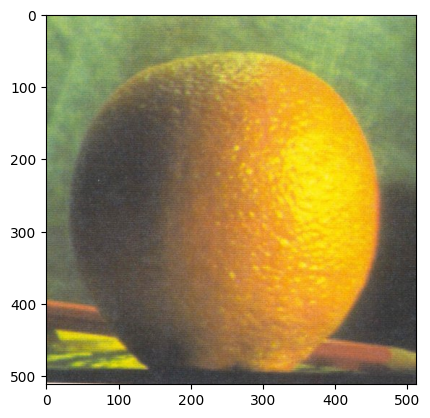

In [ ]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
#plt.axis('off')
plt.show()

# Exercícios
## 1. Visualizando cada canal
É possivel usar as facilidades de manipulação de arrays do Python para visualizar cada canal da imagem de forma independente.
Para subscrever arrays em python podemos usar ':' para indicar todos os elementos, então:

```[:,:,0]``` significa: todas a linhas e todas as colunas do canal B (lembrando que o OpenCV carrega por padrão BGR)

Complete o código abaixo para visualizar cada canal separadamente: *R*, *G* e o *B*

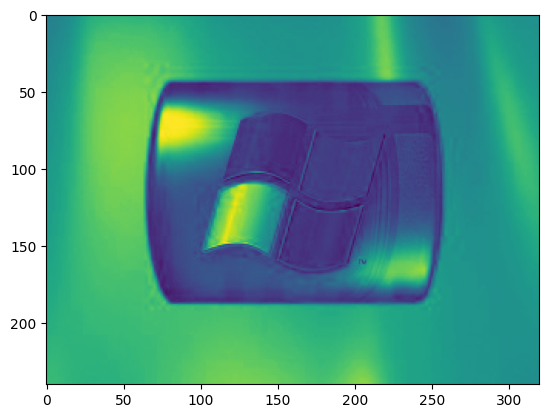

In [ ]:
img = cv.imread(cv.samples.findFile("data/WindowsLogo.jpg"))

# 1 Converter para de BGR (Padrão do OpenCV) para RGB 
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2 separar os canais
# Estrutura: img[linha, coluna, canal]
# [:,:,canal] Dessa forma pega-se todas linha e todas colunas da imagem
img_r = img_rgb[:,:,0].copy()
img_g = img_rgb[:,:,1].copy()
img_b = img_rgb[:,:,2].copy()

# Nota: Ao exibir um único canal, use cmap='gray' para ver a intensidade de cor
# plt.imshow(img_b, cmap='gray')

plt.imshow(img_b)
plt.show()

## Subplot
Matplotlib permite subdividir um gráfico em subpartes com o comando [subplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html#matplotlib.pyplot.subplot)
* Os argumentos são: Qtd. de Linhas, Qtd. de Colunas, Subgráfico que será retornada a referência
Ao visualizar imagens monocromáticas, é possível escolher um mapa de cores, vamos usar o arguemnto ```cmap='gray'``` como segundo argumento de *imshow*

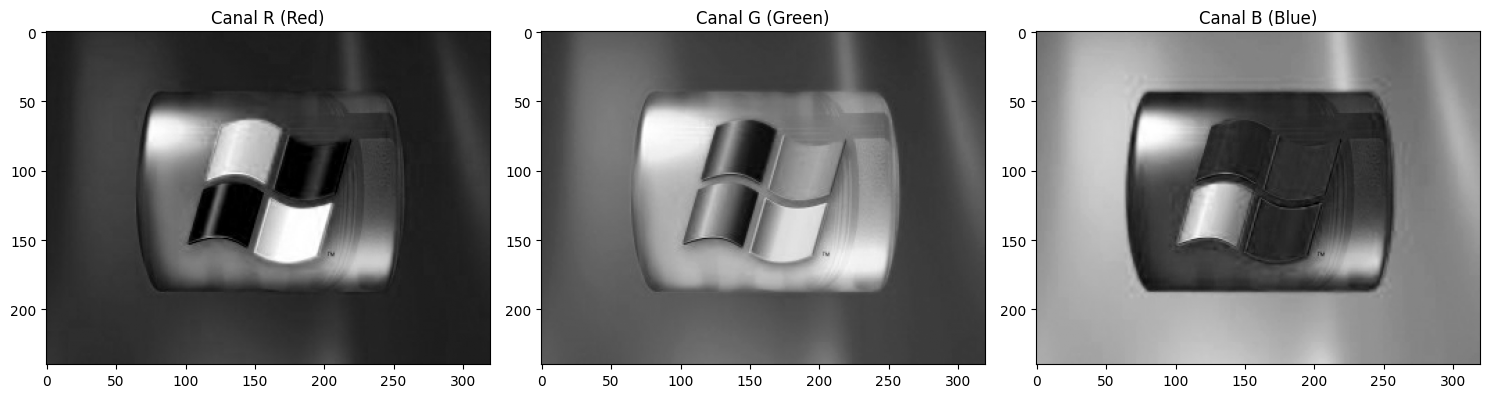

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com tamanho adequado para 3 imagens
plt.figure(figsize=(15, 5))

# --- Canal R (Vermelho) ---
ax1 = plt.subplot(1, 3, 1) # (linhas, colunas, índice) - Índice começa em 1
ax1.imshow(img_r, cmap='gray')
ax1.set_title('Canal R (Red)')
# ax1.axis('off')

# --- Canal G (Verde) ---
ax2 = plt.subplot(1, 3, 2)
ax2.imshow(img_g, cmap='gray')
ax2.set_title('Canal G (Green)')
# ax2.axis('off')

# --- Canal B (Azul) ---
ax3 = plt.subplot(1, 3, 3)
ax3.imshow(img_b, cmap='gray')
ax3.set_title('Canal B (Blue)')
# ax3.axis('off')

plt.tight_layout() # Ajusta o espaçamento automaticamente
plt.show()

## 2. Região de Interesse (ROI)
Ainda utilizando as facilidadeds do Python com arrays, podes fazer recortes na imagem. Em processamento de imagens, recortes são chamados de Regões de Interesse (ROI).
Para saber as dimensções de um array Numpy, use a proriedade *shape*. No caso sabemos que o *shape* de uma imagem colorida é Linhas, Colunas e Cores

In [ ]:
# Lines, Columns, Planes
l, c, p = img.shape
print(f'Linhas: {l}, Colunas: {c}, Planos: {p}')

Linhas: 240, Colunas: 320, Planos: 3


Para tirar recortes, use *PosiçãoInicial*:*PosiçãoFinal* nos campos de acesso do array. Exemplo:
Dado um array de 100x100, para recortar uma subarray de 5x5 elementos à partir da posição 3x4 teremos: ```sub = arr[3:7,4:8]```
Faça os seguintes recortes:
* posição 50:150, tamnho 200x200, os três canais
* posição 100x200, tamanho 200x200, apenas o canal verde
* posição 150x250, tamamho 200x200, apenas o canal vermelho

> Nota: recortes desta forma são cópias da array Numpy original, ou seja, não afetam a original

(240, 320, 3)


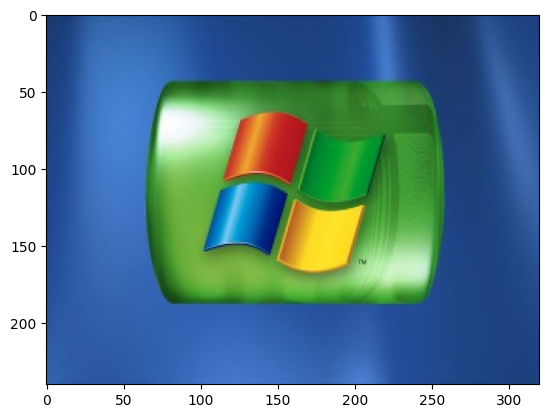

In [ ]:
img = cv.imread(cv.samples.findFile("data/WindowsLogo.jpg"))

# 1 Converter para de BGR (Padrão do OpenCV) para RGB 
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# saber quantas linhas colunas e canais tem na imagem para manipular-la
print(img_rgb.shape)
plt.imshow(img_rgb)
plt.show()

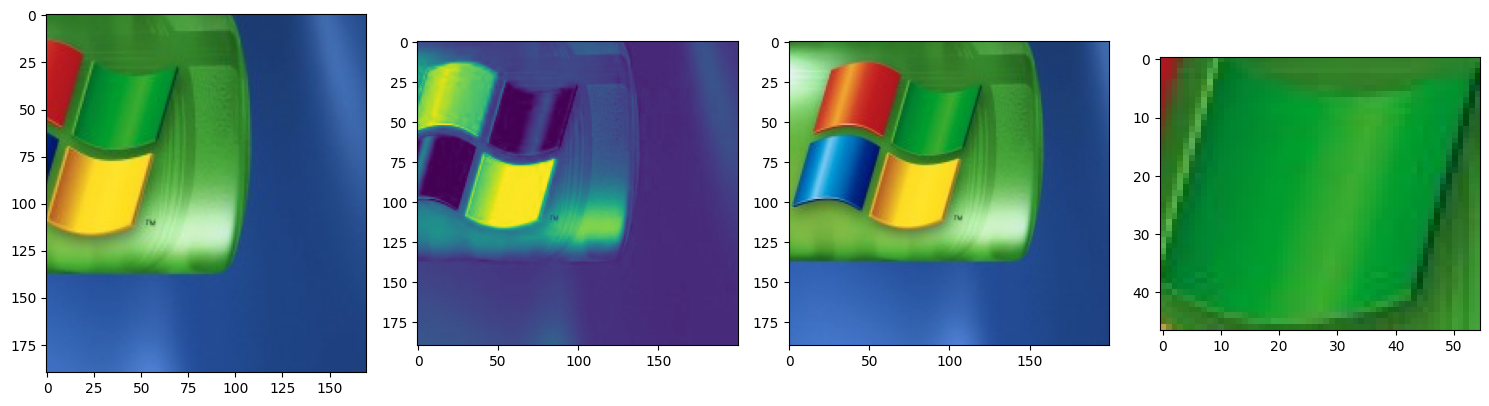

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com tamanho adequado para 3 imagens
plt.figure(figsize=(15, 5))

# 1 Posição (y=50, x=150), Tamanho 200x200, todos os canais
# Linhas: 50 até (50+200), Colunas: 150 até (150+200)
sub1 = img_rgb[50:250, 150:350, :].copy()
plt.subplot(1,4,1)
plt.imshow(sub1)
# plt.show

# 2 Posição 
sub2 = img_rgb[50:250, 120:320, 0].copy()
plt.subplot(1,4,2)
plt.imshow(sub2)
# plt.show

# 3 Posição 
sub3 = img_rgb[50:250, 100:300, :].copy()
plt.subplot(1,4,3)
plt.imshow(sub3)
# plt.show

# 4 Posição dando zoom na bandeira verde
sub4 = img_rgb[76:123, 165:220, :].copy()
plt.subplot(1,4,4)
plt.imshow(sub4)
# plt.show

plt.tight_layout() # Ajusta o espaçamento automaticamente
plt.show()

No NumPy, o tamanho da fatia é sempre calculado por:
Tamanho=Iˊndice Final−Iˊndice Inicial
Por que 50:250 resulta em 200 pixels?

Se você começa no índice 50 e quer um tamanho de 200, o seu índice final deve ser 250, porque:
250−50=200

Se o resultado fosse 200×250, isso significaria que você estaria pegando 200 linhas e 250 colunas. Mas veja como as coordenadas funcionam separadamente:
Analisando o recorte sub1 = img_rgb[50:250, 150:350, :]:

    Eixo Vertical (Y): 50:250 → Começa na linha 50 e termina antes da linha 250.

        Contagem total: 200 pixels de altura.

    Eixo Horizontal (X): 150:350 → Começa na coluna 150 e termina antes da coluna 350.

        Contagem total: 200 pixels de largura.

O resultado final do shape dessa imagem será exatamente (200, 200, 3).
A Regra de Ouro:

    O índice final é exclusivo (o Python para um antes dele).

Se você fizesse arr[0:10], você teria os índices 0, 1, 2, 3, 4, 5, 6, 7, 8, 9. Conte eles: são 10 elementos, embora o índice final seja 10.

In [ ]:
#repita de forma simiar ao código do sub plot, mostre os 3 recortes

> O exemplo abaixo modifica a array original

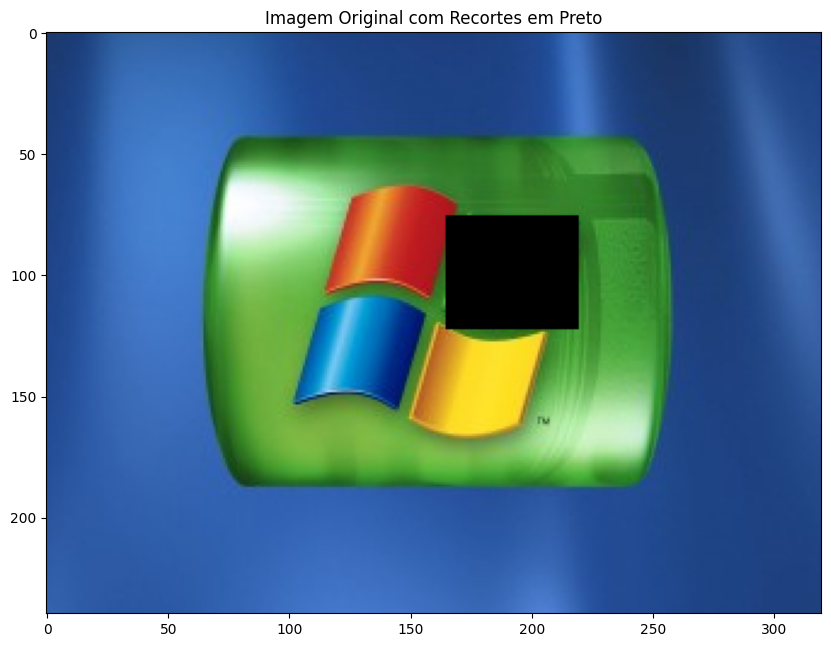

In [ ]:
import matplotlib.pyplot as plt
img = cv.imread(cv.samples.findFile("/home/jhonatan/Documentos/clound_pessoal/Processamento_imagens/data/WindowsLogo.jpg"))

# 1 Converter para de BGR (Padrão do OpenCV) para RGB 
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 1. Obter as dimensões da imagem (Linhas e Colunas)
l, c, _ = img_rgb.shape
# lc = l // 2
# cc = c // 2

# # --- OPÇÃO A: Blackout no Centro  ---
# # Cria um quadrado preto de 100x100 no centro
# img_rgb[lc-50:lc+50, cc-50:cc+50, :] = 0

# --- OPÇÃO B: Blackout na Bandeira (Coordenadas do sub4) ---
img_rgb[76:123, 165:220, :] = 0

# 2. Plotar a imagem inteira com os "buracos" pretos
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Imagem Original com Recortes em Preto")
# plt.axis('off')
plt.show()

## 3. Conversão de Cores
Vamos comprar a converão interna do OpenCV para tons de cinza (grayscale) com a conversão padronizada $L = \left|RGB\right|\times\begin{vmatrix}0.2127\\0.7152\\0.0722\end{vmatrix}$

1. Primeiro vamos mudar de BGR para RGB (ja fizemos isso, reveja o código)

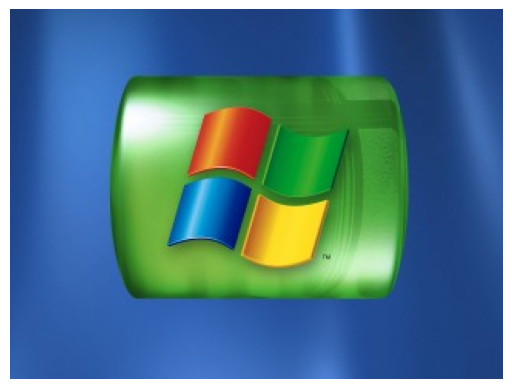

In [44]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread("/home/jhonatan/Documentos/Processamento_imagens/data/WindowsLogo.jpg")

# Converter de BGR (OpenCV) para RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

2. Depois vamos usar a conversão interna (pesquise a documentação)

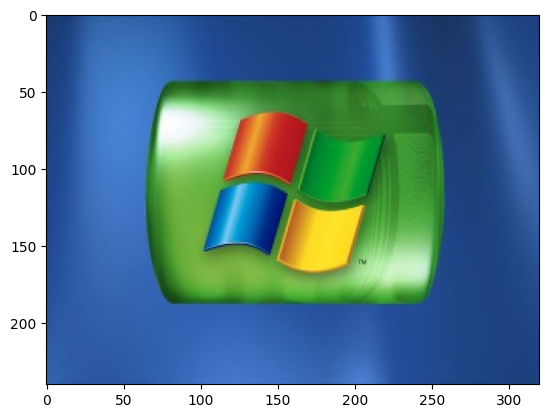

In [45]:
import matplotlib.pyplot as plt
img = cv.imread(cv.samples.findFile("/home/jhonatan/Documentos/Processamento_imagens/data/WindowsLogo.jpg"))
# Inverte apenas a ordem dos canais: [altura, largura, canais[::-1]]
imagem_rgb = img[:, :, ::-1]
plt.imshow(imagem_rgb)
plt.show()

3. Depois vamos usar a nossa conversão

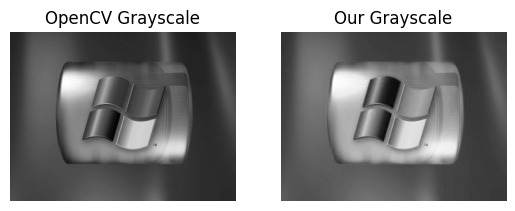

In [58]:
import numpy as np

# Conversão grayscale usando OpenCV
img_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

# Conversão manual
gray_conv = np.float32([0.2127, 0.7152, 0.0722])  # vetor de pesos

img_gray2 = img_rgb * gray_conv      # multiplica cada canal pelos pesos
img_gray2 = img_gray2[:,:,1]         # resultado fica no plano G
img_gray2 = img_gray2.astype(np.uint8)  # converter de float32 para uint8

# Plot das duas imagens
ax = plt.subplot(1, 2, 1)
ax.imshow(img_gray, cmap='gray')
ax.axis('off')
ax.set_title('OpenCV Grayscale')

ax = plt.subplot(1, 2, 2)
ax.imshow(img_gray2, cmap='gray')
ax.axis('off')
ax.set_title('Our Grayscale')

plt.show()

Imprima os valores para os pixels: (10,10), (25,30), (75,25), (200,45), (45,200) e (125,200)

Você deve encontrar como resultados:
||Calculado|OpenCV|
|---:|:---:|:---:|
|10,10|47|86|
|25,30|47|85|
|75,25|53|95|
|200,45|104|147|
|45,200|14|45|
|125,200|72|109|

In [61]:
# seu código
pixels = [(10,10), (25,30), (75,25), (200,45), (45,200), (125,200)]

print("Pixel (y,x) | Calculado | OpenCV")
print("-------------------------------")

for y, x in pixels:
    calc = img_gray2[y, x]
    opencv = img_gray[y, x]
    print(f"({y},{x})       {calc:3}        {opencv:3}")

Pixel (y,x) | Calculado | OpenCV
-------------------------------
(10,10)        44         59
(25,30)        77        102
(75,25)        78        103
(200,45)        68         90
(45,200)        72         72
(125,200)       140        170


## 4. Composição (desafio)

1. Carrege as imagens lena.jpg e baboon.jpg.
1. Confirme que ambas possuem o mesmo tamanho e imprima as dimensões de ambas.
1. Crie uma nova imagem tal que:
    * tenha as mesmas dimensões
    * Metade esquerda seja o Baboon
    * Metade direita seja a Lena
1. Mostre o resultado com Matplot

Baboon: (512, 512, 3)
Lena: (512, 512, 3)


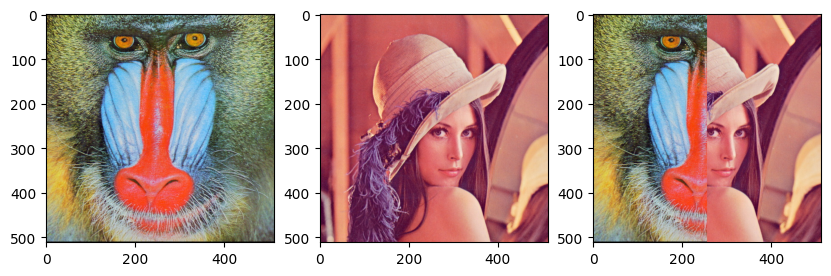

In [74]:
# seu codigo
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

img = cv.imread(cv.samples.findFile("/home/jhonatan/Documentos/Processamento_imagens/data/baboon.jpg"))
img2 = cv.imread(cv.samples.findFile("/home/jhonatan/Documentos/Processamento_imagens/data/lena.jpg"))
# Inverte apenas a ordem dos canais: [altura, largura, canais[::-1]]
imagem_rgb = img[:, :, ::-1]
imagem_rgb2 = img2[:, :, ::-1]
copy2 = imagem_rgb2.copy()
copy = img[:, :, ::-1].copy()
copy[: ,img.shape[1]//2:, :] = copy2[: ,img.shape[1]//2:, :]

# imprimir dimensões
print("Baboon:", imagem_rgb.shape)
print("Lena:", imagem_rgb2.shape)

plt.subplot(1,3,1)
plt.imshow(imagem_rgb)

plt.subplot(1,3,2)
plt.imshow(imagem_rgb2)

plt.subplot(1,3,3)
plt.imshow(copy)

plt.show()